# 02 · Modelos baseline

Se establecen modelos de referencia contra los cuales evaluar la red LSTM.

Para una comparación en igualdad de condiciones, los modelos tabulares reciben la misma información que la LSTM (los últimos 30 ciclos), resumida en *features* de ventana por sensor:

| Feature | Descripción |
|---|---|
| `_last` | valor en el ciclo actual |
| `_mean` | media móvil de la ventana |
| `_std` | desviación estándar móvil |
| `_slope` | pendiente de la regresión lineal en la ventana (tendencia) |

**Modelos:** Promedio (referencia mínima), Ridge, Random Forest y XGBoost.

**Esquema de validación:** el 20% de los motores de entrenamiento se reserva para validación, con separación por motor. El conjunto de test oficial se utiliza una única vez, en la evaluación final.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data_processing import (
    load_cmapss, add_train_rul, get_feature_columns, split_units,
    make_window_features, DEFAULT_RUL_CAP,
)
from src.models import evaluate

DATA_DIR = ROOT / "data" / "raw"
FIG_DIR = ROOT / "reports" / "figures"
MODEL_DIR = ROOT / "models"
REPORT_DIR = ROOT / "reports"
for d in (FIG_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

SUBSET = "FD001"
WINDOW = 30
SEED = 42

BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#b5b3ad"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#e6e5e0",
    "grid.linewidth": 0.6, "axes.titleweight": "bold", "lines.linewidth": 2,
})

## 1. Preparación de datos

In [2]:
train, test, rul_test = load_cmapss(DATA_DIR, SUBSET)
train = add_train_rul(train, cap=DEFAULT_RUL_CAP)
FEATURES = get_feature_columns(train)

# Features de ventana (los árboles no necesitan escalado)
train_wf = make_window_features(train, FEATURES, window=WINDOW)
test_wf = make_window_features(test, FEATURES, window=WINDOW)
X_COLS = [c for c in train_wf.columns if c not in ("unit", "cycle", "RUL", "RUL_capped")]

print(f"Sensores: {len(FEATURES)}  ->  features de ventana: {len(X_COLS)}")
train_wf[["unit", "cycle"] + X_COLS[:4] + ["RUL_capped"]].head()

Sensores: 14  ->  features de ventana: 56


,unit,cycle,s_2_last,s_2_mean,s_2_std,s_2_slope,RUL_capped
0,1,1,641.82,641.820000,0.000000,0.000,125
1,1,2,642.15,641.985000,0.233345,0.330,125
2,1,3,642.35,642.106667,0.267644,0.265,125
3,1,4,642.35,642.167500,0.250117,0.179,125
4,1,5,642.37,642.208000,0.234776,0.130,125


In [3]:
# Separación por motor: 80 motores para entrenar, 20 para validar
tr, val = split_units(train_wf, val_frac=0.2, seed=SEED)
assert set(tr["unit"]).isdisjoint(set(val["unit"])), "Fuga: un motor quedó en ambos conjuntos"

X_tr, y_tr = tr[X_COLS], tr["RUL_capped"]
X_val, y_val = val[X_COLS], val["RUL_capped"]

# Test: se evalúa en el ÚLTIMO ciclo observado de cada motor
test_last = test_wf.sort_values(["unit", "cycle"]).groupby("unit").tail(1).set_index("unit")
X_test = test_last[X_COLS]
y_test = rul_test.set_index("unit").loc[test_last.index, "RUL_end"].clip(upper=DEFAULT_RUL_CAP)

print(f"Entrenamiento: {tr['unit'].nunique()} motores, {len(tr):,} filas")
print(f"Validación   : {val['unit'].nunique()} motores, {len(val):,} filas")
print(f"Test         : {len(X_test)} motores (1 predicción por motor)")

Entrenamiento: 80 motores, 16,390 filas
Validación   : 20 motores, 4,241 filas
Test         : 100 motores (1 predicción por motor)


> La RUL de test se limita al tope de entrenamiento (125 ciclos), criterio estándar en la literatura de C-MAPSS.

## 2. Entrenamiento y validación

In [4]:
modelos = {
    "Promedio": DummyRegressor(strategy="mean"),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_leaf=5,
        max_features=0.5, n_jobs=-1, random_state=SEED),
}

resultados_val = []
for nombre, modelo in modelos.items():
    modelo.fit(X_tr, y_tr)
    resultados_val.append(evaluate(y_val, modelo.predict(X_val), nombre))
    print(f"✓ {nombre}")

✓ Promedio
✓ Ridge
✓ Random Forest


XGBoost se entrena con *early stopping* sobre el conjunto de validación (paciencia de 100 iteraciones). El número de árboles resultante se utiliza en el modelo final.

In [5]:
xgb = XGBRegressor(
    n_estimators=2000, learning_rate=0.03, max_depth=5,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=5,
    early_stopping_rounds=100, eval_metric="rmse", random_state=SEED, n_jobs=-1,
)
xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
best_n = xgb.best_iteration + 1
print(f"Mejor número de árboles: {best_n}")

modelos["XGBoost"] = xgb
resultados_val.append(evaluate(y_val, xgb.predict(X_val), "XGBoost"))

tabla_val = pd.DataFrame(resultados_val).set_index("modelo").sort_values("RMSE")
tabla_val

Mejor número de árboles: 234


,RMSE,MAE,NASA_score
modelo,,,
XGBoost,13.53,10.01,12022.0
Random Forest,13.61,10.23,12371.3
Ridge,20.77,16.91,160786.8
Promedio,41.59,37.05,1241137.4


**Métricas**

| Métrica | Definición |
|---|---|
| RMSE | Raíz del error cuadrático medio, en ciclos. Penaliza los errores grandes. |
| MAE | Error absoluto medio, en ciclos. |
| NASA score | Función de puntaje del desafío PHM08 (Saxena et al., 2008). Penalización exponencial asimétrica: castiga más las predicciones tardías (sobrestimación de la RUL), que en operación implican riesgo de falla antes del mantenimiento. Menor es mejor. |

> En validación, el NASA score se calcula sobre todos los ciclos de cada motor; en test, solo sobre el último ciclo. Sus escalas no son comparables entre conjuntos.

## 3. Evaluación en test

In [6]:
# Reentrenar con TODOS los motores de train (más datos) usando la configuración elegida
X_full, y_full = train_wf[X_COLS], train_wf["RUL_capped"]

finales = {
    "Promedio": DummyRegressor(strategy="mean"),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_leaf=5,
        max_features=0.5, n_jobs=-1, random_state=SEED),
    "XGBoost": XGBRegressor(
        n_estimators=best_n, learning_rate=0.03, max_depth=5,
        subsample=0.8, colsample_bytree=0.7, min_child_weight=5,
        random_state=SEED, n_jobs=-1),
}

pred_test, resultados_test = {}, []
for nombre, modelo in finales.items():
    modelo.fit(X_full, y_full)
    pred_test[nombre] = np.clip(modelo.predict(X_test), 0, None)  # la RUL no puede ser negativa
    resultados_test.append(evaluate(y_test, pred_test[nombre], nombre))

tabla_test = pd.DataFrame(resultados_test).set_index("modelo").sort_values("RMSE")
tabla_test

,RMSE,MAE,NASA_score
modelo,,,
XGBoost,12.57,9.66,237.2
Random Forest,13.53,10.47,296.1
Ridge,17.30,13.95,572.5
Promedio,41.94,34.83,33354.5


In [7]:
# Guardar resultados para compararlos con la LSTM en el notebook 03
tabla_test.assign(conjunto="test").to_csv(REPORT_DIR / "resultados_baselines.csv")

mejor = tabla_test.drop(index="Promedio")["RMSE"].idxmin()
joblib.dump(finales[mejor], MODEL_DIR / f"baseline_{mejor.lower().replace(' ', '_')}.joblib")
print(f"Mejor baseline en test: {mejor} (RMSE {tabla_test.loc[mejor, 'RMSE']})")

Mejor baseline en test: XGBoost (RMSE 12.57)


## 4. Análisis de errores

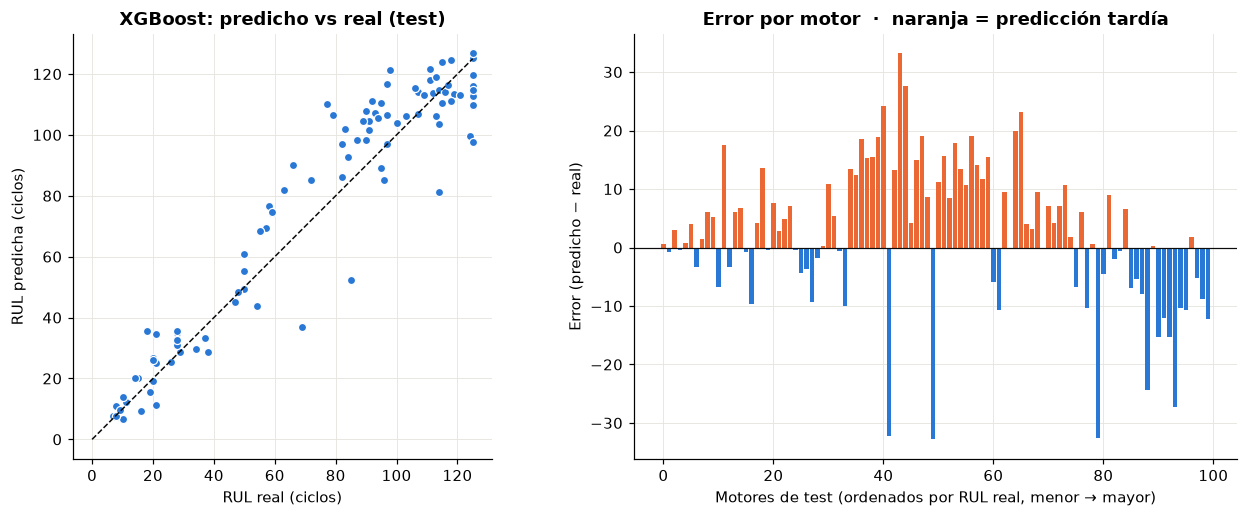

Predicciones tardías (sobrestiman la RUL): 60% de los motores


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Predicho vs real
ax = axes[0]
ax.plot([0, DEFAULT_RUL_CAP], [0, DEFAULT_RUL_CAP], color="#0b0b0b", linewidth=1, linestyle="--")
ax.scatter(y_test, pred_test[mejor], s=28, color=BLUE, edgecolor="white", linewidth=0.8)
ax.set_xlabel("RUL real (ciclos)")
ax.set_ylabel("RUL predicha (ciclos)")
ax.set_title(f"{mejor}: predicho vs real (test)")
ax.set_aspect("equal")

# Error por motor ordenado por RUL real
ax = axes[1]
orden = np.argsort(y_test.values)
err = pred_test[mejor][orden] - y_test.values[orden]
ax.bar(range(len(err)), err, color=np.where(err > 0, ORANGE, BLUE), width=0.8)
ax.axhline(0, color="#0b0b0b", linewidth=0.8)
ax.set_xlabel("Motores de test (ordenados por RUL real, menor → mayor)")
ax.set_ylabel("Error (predicho − real)")
ax.set_title("Error por motor  ·  naranja = predicción tardía")

plt.tight_layout()
plt.savefig(FIG_DIR / "07_baseline_errores_test.png", bbox_inches="tight")
plt.show()

tardias = (pred_test[mejor] > y_test.values).mean()
print(f"Predicciones tardías (sobrestiman la RUL): {tardias:.0%} de los motores")

El error es menor en motores próximos a la falla (RUL baja), donde la degradación ya se manifiesta en los sensores, y mayor en motores con RUL alta, donde la señal es débil. Este comportamiento es favorable para la planificación del mantenimiento, cuyas decisiones se concentran en el tramo de RUL baja.

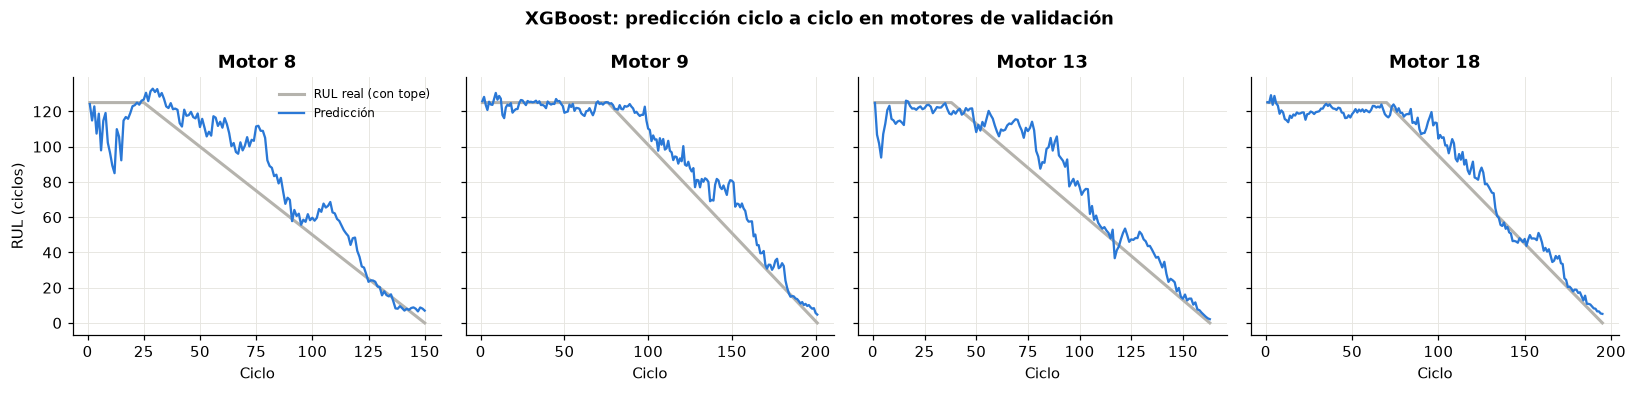

In [9]:
# Trayectoria completa de predicción para motores de validación
modelo_val = modelos[mejor]
ejemplos = val["unit"].unique()[:4]

fig, axes = plt.subplots(1, len(ejemplos), figsize=(15, 3.6), sharey=True)
for ax, u in zip(axes, ejemplos):
    g = val[val["unit"] == u]
    ax.plot(g["cycle"], g["RUL_capped"], color=GRAY, label="RUL real (con tope)")
    ax.plot(g["cycle"], modelo_val.predict(g[X_COLS]), color=BLUE, linewidth=1.5, label="Predicción")
    ax.set_title(f"Motor {u}")
    ax.set_xlabel("Ciclo")
axes[0].set_ylabel("RUL (ciclos)")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f"{mejor}: predicción ciclo a ciclo en motores de validación", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_baseline_trayectorias.png", bbox_inches="tight")
plt.show()

## 5. Importancia de variables

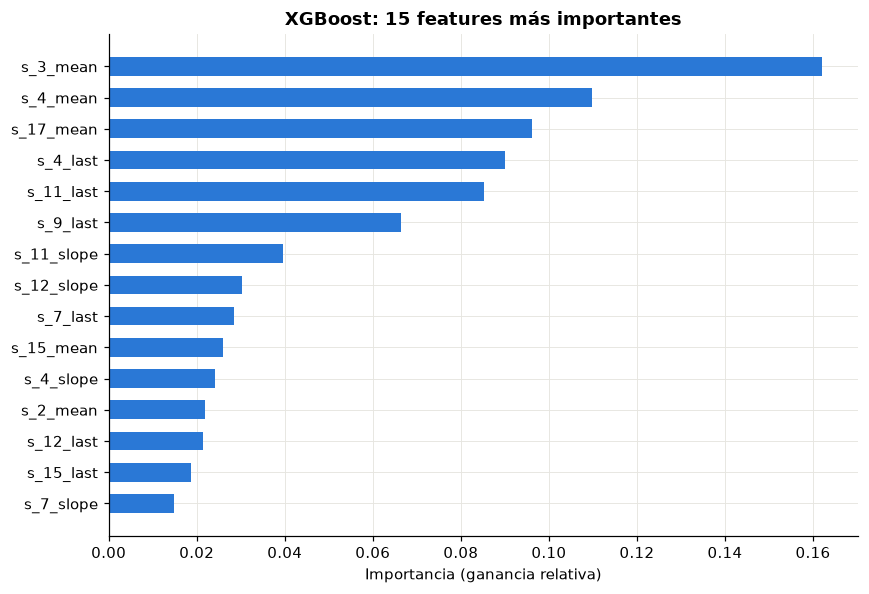

,importancia_total
mean,0.459
last,0.331
slope,0.185
std,0.025


In [10]:
xgb_final = finales["XGBoost"]
imp = (pd.Series(xgb_final.feature_importances_, index=X_COLS)
       .sort_values(ascending=True).tail(15))

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(imp.index, imp.values, color=BLUE, height=0.6)
ax.set_title("XGBoost: 15 features más importantes")
ax.set_xlabel("Importancia (ganancia relativa)")
plt.tight_layout()
plt.savefig(FIG_DIR / "09_xgboost_importancia.png", bbox_inches="tight")
plt.show()

# Importancia agregada por tipo de feature
por_tipo = (pd.Series(xgb_final.feature_importances_, index=X_COLS)
            .groupby(lambda c: c.rsplit("_", 1)[1]).sum().sort_values(ascending=False))
por_tipo.round(3).to_frame("importancia_total")

La importancia agregada por tipo de *feature* indica qué componente de la ventana (nivel, variabilidad o tendencia) aporta más información al modelo.

## 6. Conclusiones

In [11]:
print("RESULTADOS EN TEST (FD001, RUL con tope 125, último ciclo de cada motor)\n")
print(tabla_test.to_string())
base = tabla_test.loc["Promedio", "RMSE"]
print(f"\nMejora de {mejor} sobre el promedio: {(1 - tabla_test.loc[mejor, 'RMSE'] / base):.0%} menos RMSE")

RESULTADOS EN TEST (FD001, RUL con tope 125, último ciclo de cada motor)

                RMSE    MAE  NASA_score
modelo                                 
XGBoost        12.57   9.66       237.2
Random Forest  13.53  10.47       296.1
Ridge          17.30  13.95       572.5
Promedio       41.94  34.83     33354.5

Mejora de XGBoost sobre el promedio: 70% menos RMSE


- **XGBoost** obtiene el menor error en test (RMSE 12,57 ciclos; MAE 9,66), seguido de Random Forest (RMSE 13,53). Ambos reducen el RMSE en torno a un 70% respecto del modelo de referencia (41,94).
- Ridge (RMSE 17,30) presenta un desempeño inferior, consistente con una relación no lineal entre sensores y RUL.
- Las *features* de ventana capturan el nivel y la tendencia de cada sensor, lo que convierte a XGBoost en un baseline exigente.

**Siguiente etapa:** red LSTM sobre las secuencias de sensores, sin *features* diseñadas manualmente (`03_lstm.ipynb`).